 ## Ucitavanje Biblioteka i Konstatnti

In [42]:
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
from torch.nn.utils.rnn import pack_padded_sequence, pad_sequence
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
import random
from pathlib import Path
import matplotlib.pyplot as plt
import re

from collections import Counter, defaultdict

In [43]:
SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cude' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cpu


## Ucitavanje podataka

In [44]:
DATA_DIR = Path('data') / 'processed'
TRAIN_PATH = DATA_DIR / 'train.txt'
VAL_PATH = DATA_DIR / 'val.txt'
TEST_PATH = DATA_DIR / 'test.txt'

def load_split(path):
    texts, labels = [], []
    with path.open('r', encoding='utf-8') as file:
        for line_number, raw_line in enumerate(file, start=1):
            line = raw_line.strip()
            if not line:
                continue
            try:
                text, label = line.rsplit(';', maxsplit=1)
            except ValueError as error:
                raise ValueError(f'Neispravan red {line_number} u {path}: {line!r}') from error
            texts.append(text.strip())
            labels.append(label.strip())
    return texts, labels

train_texts, train_labels = load_split(TRAIN_PATH)
test_texts, test_labels = load_split(TEST_PATH)
val_texts, val_labels = load_split(VAL_PATH)

        
print(f'Trening:    {len(train_texts):>5} primera')
print(f'Validacija: {len(val_texts):>5} primera')
print(f'Test:       {len(test_texts):>5} primera')

Trening:    15983 primera
Validacija:  1997 primera
Test:        2000 primera


## Tokenizacija i Markdown

In [45]:
TOKEN_PATTERN = re.compile(r"[a-z0-9]+(?:'[a-z0-9]+)?")
PAD_TOKEN = '<pad>'
UNK_TOKEN = '<unk>'
PAD_IDX = 0
UNK_IDX = 1
MIN_FREQ = 2
MAX_VOCAB_SIZE = 20_000
MAX_SEQUENCE_LENGTH = 80

def tokenize(text):
    return TOKEN_PATTERN.findall(text.lower())

token_counts = Counter()
for text in train_texts:
    token_counts.update(tokenize(text))

frequent_tokens = [token
                  for token, frequency in token_counts.most_common()
                  if frequency >= MIN_FREQ
                  ][:MAX_VOCAB_SIZE - 2]
itos = [PAD_TOKEN, UNK_TOKEN] + frequent_tokens
stoi = {token: index for index, token in enumerate(itos)}

label_names = sorted(set(train_labels))
label_to_index = {label: index for index, label in enumerate(label_names)}

for split_name, labels in [('validacionom', val_labels), ('test', test_labels)]:
    unknown_labels = sorted(set(labels) - set(label_names))
    if unknown_labels:
        raise ValueError(f'Nepoznate oznake u {split_name} skupu: {unknown_labels}')

print(f'Broj različitih tokena u trening skupu: {len(token_counts)}')
print(f'Veličina rečnika sa posebnim tokenima: {len(itos)}')
print('Klase:', label_to_index)


Broj različitih tokena u trening skupu: 15202
Veličina rečnika sa posebnim tokenima: 7397
Klase: {'anger': 0, 'fear': 1, 'joy': 2, 'love': 3, 'sadness': 4, 'surprise': 5}


## Konverzija recnika u nizove brojeva

In [46]:
def to_numerical(text):
    token_ids = [stoi.get(token, UNK_IDX) for token in tokenize(text)]
    token_ids = token_ids[:MAX_SEQUENCE_LENGTH]
    return token_ids if token_ids else [UNK_IDX]

class EmotionDataset(Dataset):
    def __init__(self, texts, labels):
        if len(texts) != len(labels):
            raise ValueError('Broj tekstova i oznaka mora biti isti.')
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        sequence = torch.tensor(to_numerical(self.texts[index]), dtype=torch.long)
        label = torch.tensor(label_to_index[self.labels[index]], dtype=torch.long)
        return sequence, label

def collate_batch(batch):
    sequences, labels = zip(*batch)
    lengths = torch.tensor([len(sequence) for sequence in sequences], dtype=torch.long)
    padded_sequences = pad_sequence(
        sequences, batch_first=True, padding_value=PAD_IDX
    )
    labels = torch.stack(labels)
    return padded_sequences, lengths, labels

train_dataset = EmotionDataset(train_texts, train_labels)
val_dataset = EmotionDataset(val_texts, val_labels)
test_dataset = EmotionDataset(test_texts, test_labels)

BATCH_SIZE = 128
loader_generator = torch.Generator().manual_seed(SEED)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=collate_batch, num_workers=0, generator=loader_generator
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=collate_batch, num_workers=0
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=collate_batch, num_workers=0
)

example_ids = to_numerical(train_texts[0])
print('Niz indeksa:', example_ids)
example_inputs, example_lengths, example_labels = next(iter(train_loader))
print('Oblik batch tenzora posle padding-a:', example_inputs.shape)
print('Dužine prvih pet sekvenci:', example_lengths[:5].tolist())

Niz indeksa: [2, 139, 3, 679]
Oblik batch tenzora posle padding-a: torch.Size([128, 46])
Dužine prvih pet sekvenci: [14, 16, 37, 13, 6]


## LSTM Model

In [47]:
class LSTMCLassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_classes, padding_idx, num_layers=1, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx)
        self.lstm = nn.LSTM(input_size = embedding_dim, hidden_size=hidden_size,
                            num_layers=num_layers, batch_first = True, dropout = dropout if num_layers > 1 else 0.0)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, token_ids, lengths):
        embedded = self.embedding(token_ids)
        packed = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (hidden, _) = self.lstm(packed)
        final_hidden = hidden[-1]
        return self.classifier(self.dropout(final_hidden))


model = LSTMCLassifier(
    vocab_size=len(itos),
    embedding_dim=64,
    hidden_size=128,
    num_classes=len(label_names),
    padding_idx=PAD_IDX,
    num_layers=1,
    dropout=0.3
).to(device)

print(model)
        

LSTMCLassifier(
  (embedding): Embedding(7397, 64, padding_idx=0)
  (lstm): LSTM(64, 128, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=128, out_features=6, bias=True)
)


## Trening

In [48]:
def run_epoch(model, data_loader, criterion, optimizer=None):
    is_training = optimizer is not None
    model.train() if is_training else model.eval()

    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    context = torch.enable_grad() if is_training else torch.no_grad()
    with context:
        for token_ids, lengths, labels in data_loader:
            token_ids = token_ids.to(device)
            labels = labels.to(device)

            if is_training:
                optimizer.zero_grad()

            logits = model(token_ids, lengths)
            loss = criterion(logits, labels)

            if is_training:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_examples += batch_size

    return total_loss / total_examples, total_correct / total_examples

def train_model(model, train_loader, val_loader, epochs=8, learning_rate=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    history = defaultdict(list)
    best_val_loss = float('inf')
    best_state = None

    for epoch in tqdm(range(1, epochs + 1), desc='Epohe'):
        train_loss, train_accuracy = run_epoch(
            model, train_loader, criterion, optimizer
        )
        val_loss, val_accuracy = run_epoch(
            model, val_loader, criterion
        )

        history['train_loss'].append(train_loss)
        history['train_accuracy'].append(train_accuracy)
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_accuracy)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {
                name: value.detach().cpu().clone()
                for name, value in model.state_dict().items()
            }

        print(
            f'Epoha {epoch:02d} | '
            f'train loss: {train_loss:.4f}, train acc: {train_accuracy:.4f} | '
            f'val loss: {val_loss:.4f}, val acc: {val_accuracy:.4f}'
        )

    model.load_state_dict(best_state)
    return dict(history)

In [49]:
EPOCHS = 10
LEARNING_RATE = 1e-3

history = train_model(
    model, train_loader, val_loader,
    epochs=EPOCHS, learning_rate=LEARNING_RATE
)

Epohe:   0%|          | 0/10 [00:00<?, ?it/s]

Epoha 01 | train loss: 1.5952, train acc: 0.3392 | val loss: 1.5409, val acc: 0.3811
Epoha 02 | train loss: 1.4599, train acc: 0.4324 | val loss: 1.3546, val acc: 0.4867
Epoha 03 | train loss: 1.1473, train acc: 0.5814 | val loss: 1.0049, val acc: 0.6565
Epoha 04 | train loss: 0.8080, train acc: 0.7205 | val loss: 0.7566, val acc: 0.7401
Epoha 05 | train loss: 0.5671, train acc: 0.8048 | val loss: 0.5861, val acc: 0.8122
Epoha 06 | train loss: 0.4094, train acc: 0.8591 | val loss: 0.4866, val acc: 0.8483
Epoha 07 | train loss: 0.3026, train acc: 0.8936 | val loss: 0.4036, val acc: 0.8683
Epoha 08 | train loss: 0.2216, train acc: 0.9231 | val loss: 0.3941, val acc: 0.8788
Epoha 09 | train loss: 0.1663, train acc: 0.9407 | val loss: 0.3295, val acc: 0.8863
Epoha 10 | train loss: 0.1314, train acc: 0.9556 | val loss: 0.3294, val acc: 0.9009


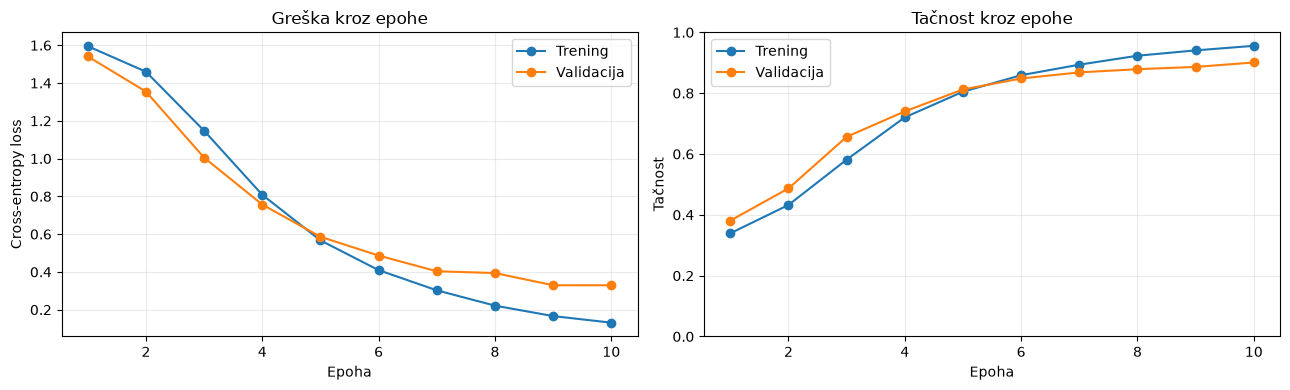

In [50]:
epochs = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(epochs, history['train_loss'], marker='o', label='Trening')
axes[0].plot(epochs, history['val_loss'], marker='o', label='Validacija')
axes[0].set(title='Greška kroz epohe', xlabel='Epoha', ylabel='Cross-entropy loss')
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(epochs, history['train_accuracy'], marker='o', label='Trening')
axes[1].plot(epochs, history['val_accuracy'], marker='o', label='Validacija')
axes[1].set(title='Tačnost kroz epohe', xlabel='Epoha', ylabel='Tačnost', ylim=(0, 1))
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

## Evaluacija modela

In [51]:
def evaluate_model(model, data_loader):
    criterion = nn.CrossEntropyLoss()
    model.eval()

    total_loss = 0.0
    total_examples = 0
    true_labels = []
    predicted_labels = []

    with torch.no_grad():
        for token_ids, lengths, labels in tqdm(data_loader, desc='Evaluacija'):
            token_ids = token_ids.to(device)
            labels = labels.to(device)
            logits = model(token_ids, lengths)
            loss = criterion(logits, labels)

            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_examples += batch_size
            true_labels.extend(labels.cpu().tolist())
            predicted_labels.extend(logits.argmax(dim=1).cpu().tolist())

    average_loss = total_loss / total_examples
    accuracy = np.mean(np.array(true_labels) == np.array(predicted_labels))
    return average_loss, accuracy, true_labels, predicted_labels

Evaluacija:   0%|          | 0/16 [00:00<?, ?it/s]

Test greška:  0.3479
Test tačnost: 0.8885

              precision    recall  f1-score   support

       anger     0.8601    0.8945    0.8770       275
        fear     0.8694    0.8616    0.8655       224
         joy     0.9055    0.9237    0.9145       695
        love     0.7662    0.7421    0.7540       159
     sadness     0.9435    0.9191    0.9311       581
    surprise     0.6984    0.6667    0.6822        66

    accuracy                         0.8885      2000
   macro avg     0.8405    0.8346    0.8374      2000
weighted avg     0.8883    0.8885    0.8883      2000



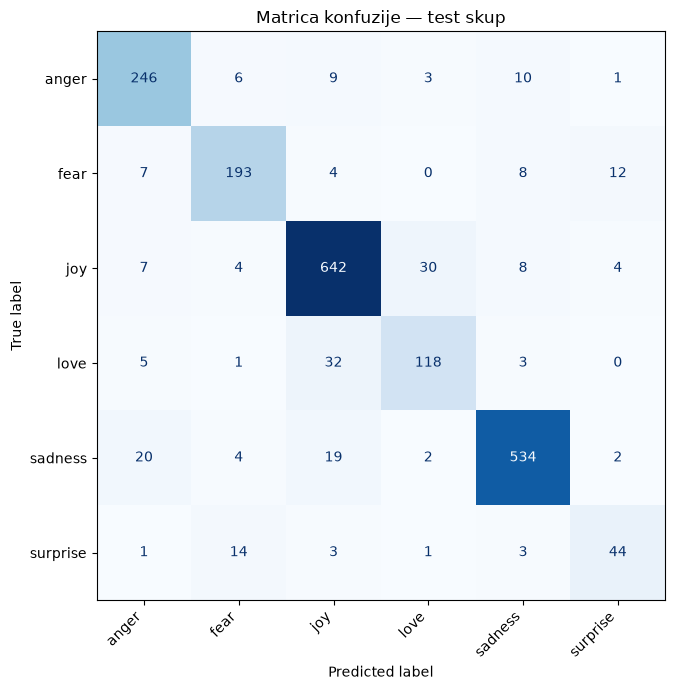

In [52]:
test_loss, test_accuracy, y_true, y_pred = evaluate_model(model, test_loader)

print(f'Test greška:  {test_loss:.4f}')
print(f'Test tačnost: {test_accuracy:.4f}')
print()
print(classification_report(
    y_true, y_pred,
    labels=list(range(len(label_names))),
    target_names=label_names,
    digits=4,
    zero_division=0,
))

cm = confusion_matrix(
    y_true, y_pred, labels=list(range(len(label_names)))
)
display = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=label_names
)
fig, ax = plt.subplots(figsize=(8, 7))
display.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
ax.set_title('Matrica konfuzije — test skup')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()